### Motion planner

In [28]:
from example_robot_data import load
from pinocchio.visualize import MeshcatVisualizer
import numpy as np
import time
import pinocchio as pin
import meshcat
import rockit
import casadi as ca
from pinocchio import casadi as cpin
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.path import Path
import heapq
from scipy.ndimage import binary_dilation

In [ ]:
# -- Define boundaries and init conditions --
x_max = 20
y_max = 15
res = 0.025

ny = int(y_max/res)
nx = int(x_max/res)
grid = np.zeros((ny, nx))

x_start, y_start = 5/res, 2/res
x_goal, y_goal = 17/res, 13/res

# -- Define obstacles corner coordinates --
obstacles = [
    [(7/res, 3/res), (8/res, 1/res), (4/res, 4/res), (8/res, 5.5/res)],
    [(2/res, 8/res), (4/res, 12/res), (8/res, 11.5/res), (9/res, 7/res), (6/res, 10/res)],
    [(13/res, 12/res), (11/res, 9/res), (16/res, 8/res)]
]


# -- Mark obstacle cells in grid --
for obs in obstacles:
    path = Path(obs)

    for y in range(ny):
        for x in range(nx):
            # Use cell center
            point = (x + 0.5, y + 0.5)

            if path.contains_point(point):
                grid[y, x] = 1

                
# -- Buffered grid --
buffer_distance = 0.3
buffer_cells = int(np.ceil(buffer_distance / res))

obstacle_grid = grid == 1

# Create circular structuring to ensure buffer in all directions
yy, xx = np.ogrid[
    -buffer_cells:buffer_cells + 1, # 
    -buffer_cells:buffer_cells + 1
]

footprint = xx**2 + yy**2 <= buffer_cells**2 # Ensure only cells within the buffer are included

inflated_obstacles = binary_dilation(obstacle_grid, structure=footprint)

grid_inflated = inflated_obstacles.astype(int)

buffer_only = (grid_inflated == 1) & (grid == 0)

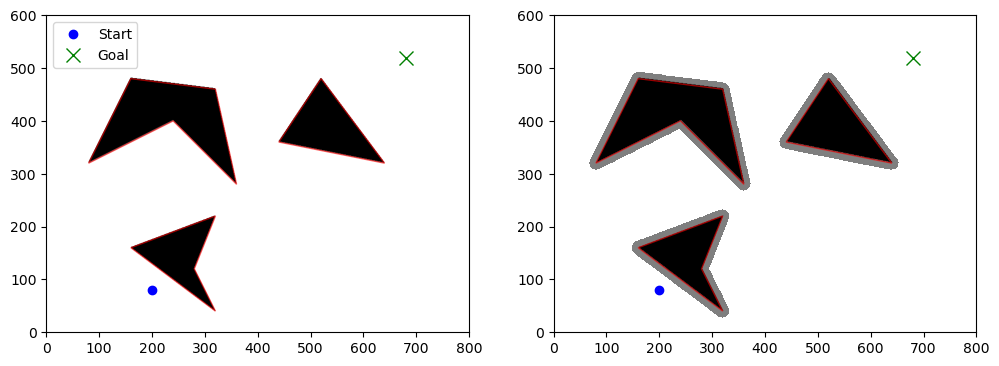

In [57]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))

ax[0].imshow(
    grid,
    cmap="Greys",
    origin="lower",
    extent=[0, nx, 0, ny]
)

ax[1].imshow(
    grid,
    cmap="Greys",
    origin="lower",
    extent=[0, nx, 0, ny]
)

# ax[1].imshow(
#     buffer_only,
#     cmap="Reds",
#     origin="lower",
#     extent=[0, nx, 0, ny],
#     alpha=0.5
# )
ax[1].contourf(buffer_only, levels=[0.5, 1.5], colors=['none', 'blue'], alpha=0.5, origin='lower')

# Plot filled polygon obstacles
for obs in obstacles:
    poly = Polygon(obs, closed=True, facecolor="black", edgecolor="red", alpha=0.6)
    ax[0].add_patch(poly)
    poly = Polygon(obs, closed=True, facecolor="black", edgecolor="red", alpha=0.6)
    ax[1].add_patch(poly)

# Plot start and goal
for a in ax:
    a.plot(x_start, y_start, "bo", label="Start")
    a.plot(x_goal, y_goal, "gx", markersize=10, label="Goal")
    a.set_xlim(0, nx)
    a.set_ylim(0, ny)
    a.set_aspect("equal")

ax[0].legend()

plt.show()

In [26]:

def aStarSearch(grid, start, goal, connectivity=8):
    """Search the node that has the lowest combined cost and heuristic first."""
    # Astar: f(n) = g(n) + h(n) | g(n) = cost, h(n) = heuristic distance
    # 4-connectivity
    if connectivity == 4:
        neighbours = [(0, 1), (0, -1), (1, 0), (-1, 0)]
    # 8-connectivity
    elif connectivity == 8:
        neighbours = [(0, 1), (0, -1), (1, 0), (-1, 0), (1, 1), (1, -1), (-1, 1), (-1, -1)]
    else: 
        raise ValueError("Invalid connectivity. Valid options: 4, 8.")
    frontier = []

    #heapq.heappush(frontier, (0, start))
    heapq.heappush(frontier, (heuristic(start, goal, connectivity), start))

    prev_state = {}
    path = []
    best_g = {start: 0}
    print(frontier)

    while frontier:
        _, state = heapq.heappop(frontier)

        cx, cy = state

        if state == goal:
            print("Goal found")

            path = [state]
            while state in prev_state:
                state = prev_state[state]
                path.append(state)

            path.reverse()
            return path
        
        for i, j in neighbours:
            new_state = cx + i, cy + j
            # skip if out of bounds
            if not (0 <= new_state[0] < grid.shape[1] and 0 <= new_state[1] < grid.shape[0]):
                continue
            # skip if obstacle
            if grid[new_state[1], new_state[0]] == 1:
                continue

            if connectivity == 4:
                # uniform cost
                new_g = best_g[state] + 1
            
            else:
                # Diagonal cost is slightly higher than orthogonal cost
                new_g = best_g[state] + np.sqrt((state[0]-new_state[0])**2 + (state[1]-new_state[1])**2)

            if new_g < best_g.get(new_state, float('inf')):
                best_g[new_state] = new_g
                h = heuristic(new_state, goal, connectivity)
                f = new_g + h
                heapq.heappush(frontier, (f, new_state))
                prev_state[new_state] = state


    return []

def heuristic(a, b, connectivity=8):
    """Manhatten or Euclidean distance??"""
    x1, y1 = a
    x2, y2 = b
    if connectivity == 4:
        return np.abs(x1 - x2) + np.abs(y1 - y2) # manhattan
    if connectivity == 8:
        return np.sqrt((x1 - x2)**2 + (y1 - y2)**2) # euclidean



In [21]:
def line_is_free(grid, p1, p2):
    x0, y0 = p1
    x1, y1 = p2

    n = int(max(abs(x1 - x0), abs(y1 - y0)))

    for k in range(n + 1):
        t = k / max(n, 1)
        x = int(round(x0 + t * (x1 - x0)))
        y = int(round(y0 + t * (y1 - y0)))

        if not (0 <= x < grid.shape[1] and 0 <= y < grid.shape[0]):
            return False

        if grid[y, x] == 1:
            return False

    return True


def smooth_path(grid, path):
    if len(path) <= 2:
        return path

    smoothed = [path[0]]
    i = 0

    while i < len(path) - 1:
        j = len(path) - 1

        while j > i + 1:
            if line_is_free(grid, path[i], path[j]):
                break
            j -= 1

        smoothed.append(path[j])
        i = j

    return smoothed

[(0, (200, 80))]
Goal found
[(0, (200, 80))]
Goal found


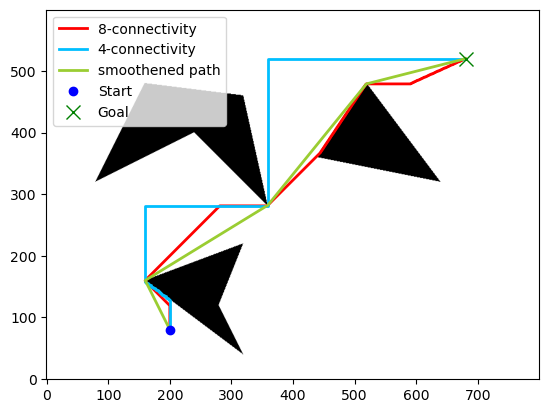

In [25]:
path_8 = aStarSearch(grid, (int(x_start), int(y_start)), (int(x_goal), int(y_goal)), connectivity=8)
path_8 = np.array(path_8)
path_4 = aStarSearch(grid, (int(x_start), int(y_start)), (int(x_goal), int(y_goal)), connectivity=4)
path_4 = np.array(path_4)

smooth = smooth_path(grid=grid, path=path_8)
smooth = np.array(smooth)

plt.imshow(grid, cmap='Greys', origin='lower')
plt.plot(path_8[:,0], path_8[:,1], color='red', linewidth=2, label='8-connectivity')
plt.plot(path_4[:,0], path_4[:, 1], color='deepskyblue', linewidth=2, label='4-connectivity')
plt.plot(smooth[:,0], smooth[:, 1], color='yellowgreen', linewidth=2, label='smoothened path')
plt.plot(x_start, y_start, "bo", label="Start")
plt.plot(x_goal, y_goal, "gx", markersize=10, label="Goal")
plt.legend()
plt.show()

[(np.float64(651.1528238439882), (200, 80))]
Goal found
[(np.int64(920), (200, 80))]
Goal found


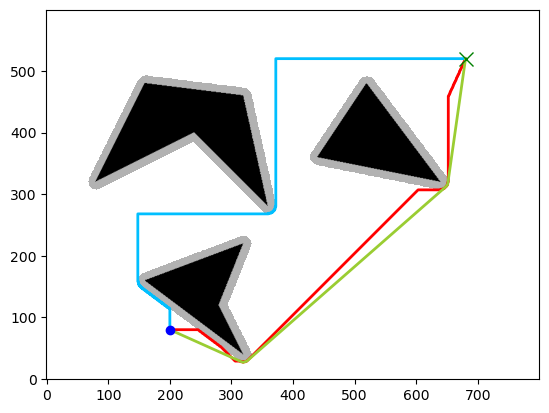

In [54]:
path_8 = aStarSearch(grid_inflated, (int(x_start), int(y_start)), (int(x_goal), int(y_goal)), connectivity=8)
path_8 = np.array(path_8)
path_4 = aStarSearch(grid_inflated, (int(x_start), int(y_start)), (int(x_goal), int(y_goal)), connectivity=4)
path_4 = np.array(path_4)

smooth = smooth_path(grid=grid_inflated, path=path_8)
smooth = np.array(smooth)

plt.imshow(grid, cmap='Greys', origin='lower')
#plt.imshow(buffer_only, cmap='grey', vmin=0, vmax=1,origin='lower', alpha=0.5)
plt.contourf(buffer_only, levels=[0.5, 1.5], colors=['none', 'red'], alpha=0.3, origin='lower')
plt.plot(path_8[:,0], path_8[:,1], color='red', linewidth=2, label='8-connectivity')
plt.plot(path_4[:,0], path_4[:, 1], color='deepskyblue', linewidth=2, label='4-connectivity')
plt.plot(smooth[:,0], smooth[:, 1], color='yellowgreen', linewidth=2, label='smoothened path')
plt.plot(x_start, y_start, "bo", label="Start")
plt.plot(x_goal, y_goal, "gx", markersize=10, label="Goal")
#plt.legend()
plt.show()

[(np.float64(651.1528238439882), (200, 80))]
Goal found
[(np.int64(920), (200, 80))]
Goal found
[(np.float64(651.1528238439882), (200, 80))]
Goal found
[(np.int64(920), (200, 80))]
Goal found


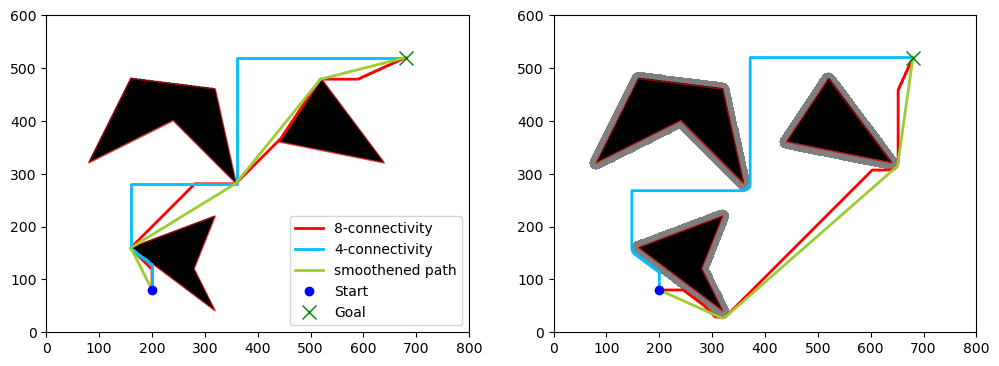

In [59]:
path_8 = aStarSearch(grid, (int(x_start), int(y_start)), (int(x_goal), int(y_goal)), connectivity=8)
path_8 = np.array(path_8)
path_4 = aStarSearch(grid, (int(x_start), int(y_start)), (int(x_goal), int(y_goal)), connectivity=4)
path_4 = np.array(path_4)

smooth = smooth_path(grid=grid, path=path_8)
smooth = np.array(smooth)

path_8_buf = aStarSearch(grid_inflated, (int(x_start), int(y_start)), (int(x_goal), int(y_goal)), connectivity=8)
path_8_buf = np.array(path_8_buf)
path_4_buf = aStarSearch(grid_inflated, (int(x_start), int(y_start)), (int(x_goal), int(y_goal)), connectivity=4)
path_4_buf = np.array(path_4_buf)

smooth_buf = smooth_path(grid=grid_inflated, path=path_8_buf)
smooth_buf = np.array(smooth_buf)

fig, ax = plt.subplots(1,2, figsize=(12, 6))

ax[0].imshow(
    grid,
    cmap="Greys",
    origin="lower",
    extent=[0, nx, 0, ny]
)
ax[0].plot(path_8[:,0], path_8[:,1], color='red', linewidth=2, label='8-connectivity')
ax[0].plot(path_4[:,0], path_4[:, 1], color='deepskyblue', linewidth=2, label='4-connectivity')
ax[0].plot(smooth[:,0], smooth[:, 1], color='yellowgreen', linewidth=2, label='smoothened path')

ax[1].imshow(
    grid,
    cmap="Greys",
    origin="lower",
    extent=[0, nx, 0, ny]
)
ax[1].contourf(buffer_only, levels=[0.5, 1.5], colors=['none', 'blue'], alpha=0.5, origin='lower')
ax[1].plot(path_8_buf[:,0], path_8_buf[:,1], color='red', linewidth=2, label='8-connectivity')
ax[1].plot(path_4_buf[:,0], path_4_buf[:, 1], color='deepskyblue', linewidth=2, label='4-connectivity')
ax[1].plot(smooth_buf[:,0], smooth_buf[:, 1], color='yellowgreen', linewidth=2, label='smoothened path')

# Plot filled polygon obstacles
for obs in obstacles:
    poly = Polygon(obs, closed=True, facecolor="black", edgecolor="red", alpha=0.6)
    ax[0].add_patch(poly)
    poly = Polygon(obs, closed=True, facecolor="black", edgecolor="red", alpha=0.6)
    ax[1].add_patch(poly)

# Plot start and goal
for a in ax:
    a.plot(x_start, y_start, "bo", label="Start")
    a.plot(x_goal, y_goal, "gx", markersize=10, label="Goal")
    a.set_xlim(0, nx)
    a.set_ylim(0, ny)
    a.set_aspect("equal")

ax[0].legend()

plt.show()

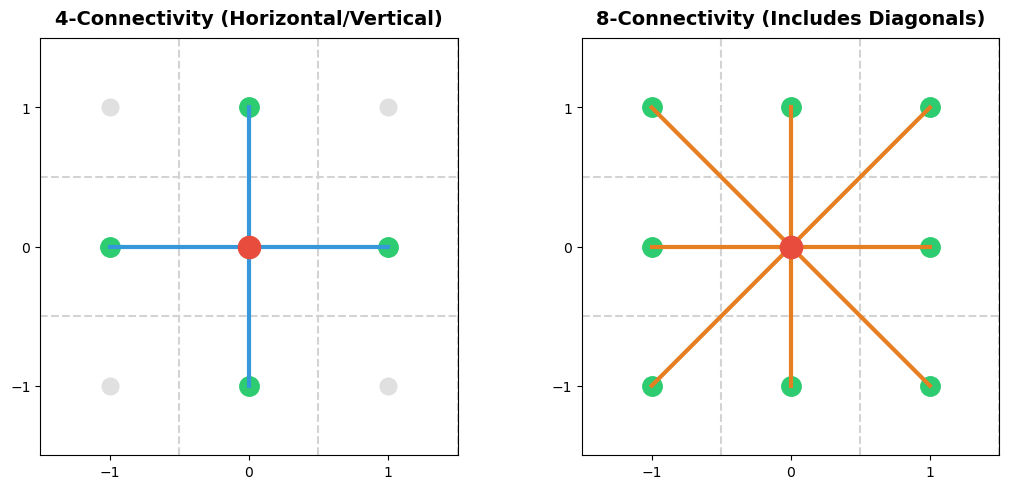

In [68]:
import matplotlib.pyplot as plt

def draw_grid_connectivity(connectivity, ax, title, line_color):
    # Set coordinate boundaries for a 3x3 neighborhood
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    
    # Draw pixel grid borders
    for i in range(4):
        ax.axhline(i - 0.5, color='lightgray', linestyle='--', zorder=1)
        ax.axvline(i - 0.5, color='lightgray', linestyle='--', zorder=1)
        
    cx, cy = 0, 0  # Coordinates for the central pixel
    
    # Define neighborhood offsets
    if connectivity == 4:
        neighbors = [(0, 1), (0, -1), (1, 0), (-1, 0)]  # North, South, East, West
    elif connectivity == 8:
        neighbors = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]  # All 8 surrounding
        
    # Draw base pixel placeholders
    for x in range(-1,2):
        for y in range(-1, 2):
            ax.plot(x, y, 'o', color='#E0E0E0', markersize=12, zorder=2)
            
    # Highlight connected neighbors and draw the connectivity edges
    for nx, ny in neighbors:
        ax.plot(nx, ny, 'o', color='#2ECC71', markersize=14, zorder=3)
        ax.plot([cx, nx], [cy, ny], color=line_color, linewidth=3, zorder=4)
        
    # Draw the target center pixel
    ax.plot(cx, cy, 'o', color='#E74C3C', markersize=16, zorder=5)
    
    # Formatting adjustments
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])
    ax.set_aspect('equal')
    ax.grid(False)

# Initialize the plot layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

# Generate both visualizations
draw_grid_connectivity(4, ax1, "4-Connectivity (Horizontal/Vertical)", "#3498DB")
draw_grid_connectivity(8, ax2, "8-Connectivity (Includes Diagonals)", "#E67E22")

plt.tight_layout()
plt.show()